<a href="https://colab.research.google.com/github/SindhuMH/cartoon_generator/blob/image_generator_codes/stage2_asset_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 2 Asset Generator — Colab Edition

Generates character reference images and place/background images for a story, using a shared "style bible" so every asset stays visually consistent — same approach as the local script, but running on Colab's free/Pro GPU instead of a paid API.

**Model:** FLUX.1 [schnell] (Apache 2.0 — commercial-friendly, ungated on Hugging Face)

**Runtime:** Runtime -> Change runtime type -> T4 GPU (free tier) or A100 (Pro) before running.

## 1. Install dependencies

In [1]:
!pip install -q diffusers transformers accelerate sentencepiece protobuf

## 2. Mount Google Drive

Keeps your generated assets persistent across Colab sessions instead of vanishing when the runtime disconnects.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_ROOT = '/content/drive/MyDrive/panchatantra_assets'
import os
os.makedirs(OUTPUT_ROOT, exist_ok=True)

Mounted at /content/drive


## 3. Story config (style bible + characters + places)

Edit this dict per story — same schema as the local `config/*.json` files, just pasted inline here. Copy a story's JSON in directly if you already have one saved in Drive.

In [5]:
config = {
  "story_id": "monkey_and_crocodile",
  "style": {
    "art_style": "flat 2D vector illustration for children's storybook, warm pastel color palette, thick clean outlines, soft rounded shapes, simple gradients, gentle lighting, Indian folk-art influenced background patterns",
    "negative_prompt": "photorealistic, 3d render, realistic skin, watermark, text, signature, blurry, extra limbs, deformed, low quality",
    "character_size": [1024, 1024],
    "place_size": [1344, 768]
  },
  "characters": [
    {
      "id": "monkey",
      "name": "Chintu the Monkey",
      "description": "a friendly young brown monkey with big expressive round eyes, wearing a small red vest, long curled tail, cheerful open-mouth smile, standing pose, full body, plain neutral background"
    },
    {
      "id": "crocodile",
      "name": "Kalu the Crocodile",
      "description": "a chubby green crocodile with rounded snout, small friendly eyes, textured back scales stylized as soft bumps, short stubby legs, standing pose, full body, plain neutral background"
    }
  ],
  "places": [
    {
      "id": "riverbank",
      "name": "River Bank",
      "description": "a lush green riverbank at soft morning light, a large fruit tree with overhanging branches on one side, calm blue river with gentle ripples, distant hills, wide establishing shot, no characters"
    },
    {
      "id": "river_middle",
      "name": "Middle of the River",
      "description": "view from the surface of a calm wide river, gentle ripples, soft morning sky reflected in the water, a few lily pads, wide shot, no characters"
    }
  ]
}

VARIANTS_PER_SUBJECT = 4

## 4. Load the model
One-time load per session — takes a minute or two.

In [7]:
import torch
from diffusers import FluxPipeline
import huggingface_hub

huggingface_hub.login()

pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-schnell",
    torch_dtype=torch.bfloat16
)
# pipe.enable_model_cpu_offload()  # helps fit on free-tier T4 (16GB)

pipe.enable_sequential_cpu_offload()
pipe.enable_attention_slicing()
pipe.vae.enable_slicing()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

## 5. Generation functions

In [8]:
import json
from pathlib import Path

def build_prompt(subject_description, style):
    return f"{subject_description}, {style['art_style']}"

def generate_variants(subject_id, subject_description, style, size, out_dir, num_variants, manifest, category):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    prompt = build_prompt(subject_description, style)
    full_prompt = f"{prompt}. Avoid: {style.get('negative_prompt', '')}."

    manifest_entry = {"prompt": full_prompt, "variants": []}

    for i in range(1, num_variants + 1):
        print(f"  [{category}:{subject_id}] generating variant {i}/{num_variants}...")
        image = pipe(
            prompt=full_prompt,
            width=size[0],
            height=size[1],
            guidance_scale=0.0,   # schnell is a distilled turbo model, no CFG needed
            num_inference_steps=4,
            generator=torch.Generator("cpu").manual_seed(1000 + i),
        ).images[0]

        variant_path = out_dir / f"variant_{i}.png"
        image.save(variant_path)
        manifest_entry["variants"].append(str(variant_path))

    manifest[category][subject_id] = manifest_entry

## 6. Run generation for all characters and places

In [9]:
story_id = config["story_id"]
style = config["style"]
base_dir = Path(OUTPUT_ROOT) / story_id

manifest = {"story_id": story_id, "style": style, "characters": {}, "places": {}}

for char in config.get("characters", []):
    generate_variants(
        subject_id=char["id"],
        subject_description=char["description"],
        style=style,
        size=style["character_size"],
        out_dir=base_dir / "characters" / char["id"],
        num_variants=VARIANTS_PER_SUBJECT,
        manifest=manifest,
        category="characters",
    )

for place in config.get("places", []):
    generate_variants(
        subject_id=place["id"],
        subject_description=place["description"],
        style=style,
        size=style["place_size"],
        out_dir=base_dir / "places" / place["id"],
        num_variants=VARIANTS_PER_SUBJECT,
        manifest=manifest,
        category="places",
    )

manifest_path = base_dir / "manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Done. Manifest written to {manifest_path}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (107 > 77). Running this sequence through the model will result in indexing errors
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CLIPTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['patterns . avoid : photorealistic , 3 d render , realistic skin , watermark , text , signature , blurry , extra limbs , deformed , low quality .']


  [characters:monkey] generating variant 1/4...


  0%|          | 0/4 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['patterns . avoid : photorealistic , 3 d render , realistic skin , watermark , text , signature , blurry , extra limbs , deformed , low quality .']


  [characters:monkey] generating variant 2/4...


...

  0%|          | 0/4 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['photorealistic , 3 d render , realistic skin , watermark , text , signature , blurry , extra limbs , deformed , low quality .']


  [places:river_middle] generating variant 4/4...


  0%|          | 0/4 [00:00<?, ?it/s]

Done. Manifest written to /content/drive/MyDrive/panchatantra_assets/monkey_and_crocodile/manifest.json


## 7. Review variants and pick canonical images

Shows a thumbnail grid per character/place so you can pick the best one without leaving the notebook. Set `CHOSEN` below after looking at the grid, then run the save cell.

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

def show_variants(category, subject_id):
    entry = manifest[category][subject_id]
    fig, axes = plt.subplots(1, len(entry["variants"]), figsize=(4 * len(entry["variants"]), 4))
    for ax, path in zip(axes, entry["variants"]):
        ax.imshow(Image.open(path))
        ax.set_title(Path(path).name)
        ax.axis("off")
    plt.suptitle(f"{category}: {subject_id}")
    plt.show()

# Example: show_variants("characters", "monkey")

In [11]:
def set_canonical(category, subject_id, variant_number):
    entry = manifest[category][subject_id]
    src = Path(entry["variants"][variant_number - 1])
    dst = src.parent / "canonical.png"
    dst.write_bytes(src.read_bytes())
    print(f"canonical set: {dst}")

# Example usage after reviewing the grid above:
# set_canonical("characters", "monkey", 2)
# set_canonical("places", "riverbank", 1)

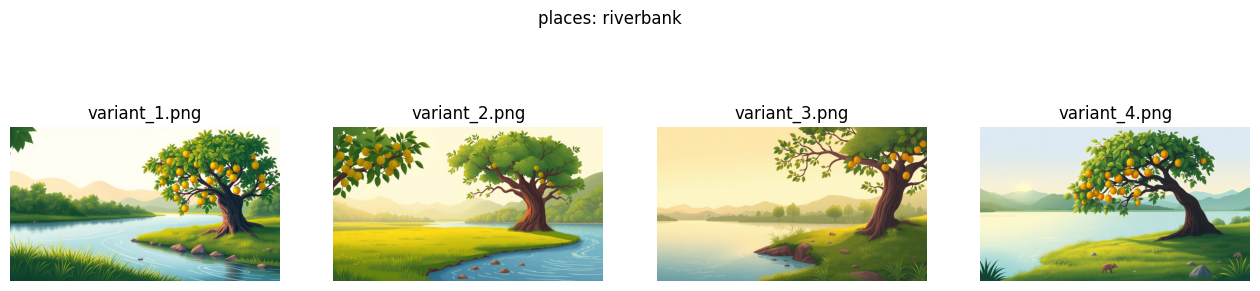

In [12]:
show_variants("places", "riverbank")